In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
def R21(t): return 2
def R22(t): return 1.5

def x1(t):
    # Крива Г1 (розімкнена дуга всередині області)
    return np.array([0.5 * t, 0.5 * (t**2 - 0.5)])

def x2(t):
    # Крива Г2 (зовнішня межа - еліпс)
    return np.array([R21(t) * np.cos(t), R22(t) * np.sin(t)])

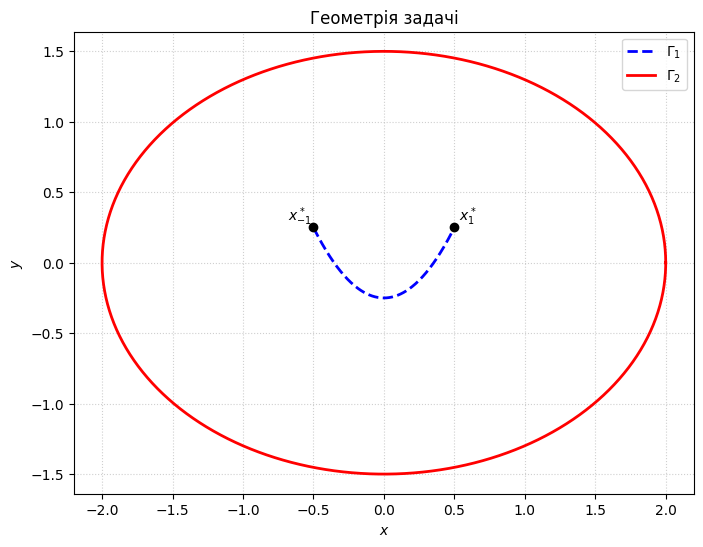

In [3]:
# Генерація точок для Г1 (t від -1 до 1)
t1_vals = np.linspace(-1, 1, 200)
gamma1 = np.array([x1(t) for t in t1_vals]).T

# Генерація точок для Г2 (t від 0 до 2*pi)
t2_vals = np.linspace(0, 2 * np.pi, 400)
gamma2 = np.array([x2(t) for t in t2_vals]).T

# Побудова графіка
plt.figure(figsize=(8, 6))
plt.plot(gamma1[0], gamma1[1], label='$\Gamma_1$', color='blue', linestyle='--', linewidth=2)
plt.plot(gamma2[0], gamma2[1], label='$\Gamma_2$', color='red', linewidth=2)

plt.scatter([gamma1[0, 0], gamma1[0, -1]], [gamma1[1, 0], gamma1[1, -1]], color='black', zorder=5)
plt.annotate('$x_{-1}^*$', (gamma1[0, 0], gamma1[1, 0]), textcoords="offset points", xytext=(-10,5), ha='center')
plt.annotate('$x_{1}^*$', (gamma1[0, -1], gamma1[1, -1]), textcoords="offset points", xytext=(10,5), ha='center')

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Геометрія задачі')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')
plt.show()

In [4]:
def x1_deriv1_mod(sigma):
    dx_dsigma = 0.5
    dy_dsigma = sigma
    return np.sqrt(dx_dsigma**2 + dy_dsigma**2)

def x2_deriv1_mod(t):
    dx_dt = - R21(t)*math.sin(t)
    dy_dt = R22(t)*math.cos(t)
    return np.sqrt(dx_dt**2 + dy_dt**2)

In [5]:
y_star = np.array([3.0, 3.0]) 

def exact_u(x): 
    return x[0]**2 - x[1]**2 

def f1(x):
    return exact_u(x)

def f2(x):
    return exact_u(x)

In [6]:
def H11(s, sigma):
    if abs(np.cos(s) - np.cos(sigma)) < 1e-12:
        mod = x1_deriv1_mod(np.cos(s))
        return np.log(2 / (np.e * mod))
    else:
        num = 2 * abs(np.cos(s) - np.cos(sigma))
        den = np.e * np.linalg.norm(x1(np.cos(s)) - x1(np.cos(sigma)))
        return np.log(num / den)

def H12(s, tau):
    return np.log(1 / np.linalg.norm(x1(np.cos(s)) - x2(tau)))

def H21(t, sigma):
    return np.log(1 / np.linalg.norm(x2(t) - x1(np.cos(sigma))))

def H22(t, tau):
    if abs(t - tau) < 1e-12:
        mod = x2_deriv1_mod(t)
        return 0.5 * np.log(1 / (np.e * (mod**2)))
    else:
        num = (4 / np.e) * (np.sin((t - tau) / 2)**2)
        den = np.linalg.norm(x2(t) - x2(tau))**2
        return 0.5 * np.log(num / den)

In [7]:
def t(j, n):
    return (j * np.pi) / n

def R(j, t_val, n):
    s = 0
    t_diff = t_val - t(j,n)

    for m in range(1,n):
        s += (math.cos(m * (t_diff)) / m )

    result = (s + ((math.cos(n*(t_diff))) / (2*n))) / (-n)
    return result - 1 / (2*n)


In [ ]:
def save_data(filename, n, label, data):
    with open(filename, 'a') as f:
        f.write(f"\n{'='*20}\n")
        f.write(f" n = {n} | Matrix: {label}\n")
        f.write(f"{'='*20}\n")
        np.savetxt(f, data, fmt='%0.6f')

In [9]:
def FormMatr(n):
    size = 4 * n
    matrix = np.zeros((size, size))
    
    for i in range(2 * n):
        si = t(i, n)
        for j in range(2 * n):
            sj = t(j, n)
            
            # Рівняння 1 (на Г1)
            # Коефіцієнти при mu1
            matrix[i, j] = 0.5 * (-0.5 * R(j, si, n) + (1 / (2 * n)) * H11(si, sj))
            # Коефіцієнти при mu2
            matrix[i, j + 2 * n] = (1 / (2 * n)) * H12(si, sj)
            
            # Рівняння 2 (на Г2)
            # Коефіцієнти при mu1
            matrix[i + 2 * n, j] = 0.5 * (1 / (2 * n)) * H21(si, sj)
            # Коефіцієнти при mu2
            matrix[i + 2 * n, j + 2 * n] = -0.5 * R(j, si, n) + (1 / (2 * n)) * H22(si, sj)

    return matrix

def FormVector(n):
    vector = np.zeros(4 * n)
    for i in range(2 * n):
        ti = t(i, n)
        vector[i] = f1(x1(np.cos(ti)))
        vector[i + 2 * n] = f2(x2(ti))
    return vector

def FormPhi(n):
    matrix = FormMatr(n)
    vector = FormVector(n)
    return np.linalg.solve(matrix, vector)


In [10]:
def solving(n, x_target):
    phi = FormPhi(n)
    
    mu1, mu2 = np.split(phi, 2)
    
    tj = t(np.arange(2 * n), n)

    sum1 = 0
    for j in range(2 * n):
        dist1 = np.linalg.norm(x_target - x1(np.cos(tj[j])))
        sum1 += mu1[j] * 0.5 * np.log(1 / dist1)
            
    sum2 = 0
    for j in range(2 * n):
        dist2 = np.linalg.norm(x_target - x2(tj[j]))
        sum2 += mu2[j] * np.log(1 / dist2)
            
    return (sum1 + sum2) / (2 * n)


x_test = np.array([0, 0])
u_ex = exact_u(x_test)
numbers = [8, 16, 32, 64]

print(f"Точне значення u({x_test}) = {u_ex:.15f}\n")
print("n    |  Наближене u   |  Похибка")
print("-" * 40)
for n in numbers:
    try:
        u_app = solving(n, x_test)
        error = abs(u_app - u_ex)
        print(f"{n:<4}| {u_app:.15f} | {error:.2e}")
    except np.linalg.LinAlgError:
        print(f"{n:<4}: Помилка (Матриця вироджена)")

Точне значення u([0 0]) = 0.000000000000000

n    |  Наближене u   |  Похибка
----------------------------------------
8   | -0.000000486611112 | 4.87e-07
16  | -0.000000000000058 | 5.80e-14
32  | 0.000000000000001 | 7.18e-16
64  | -0.000000000000000 | 2.30e-16


In [ ]:
def x2_deriv1_coord(t, coord):
    if coord == 1:
        return -R21(t)*math.sin(t)
    elif coord == 2:
        return R22(t)*math.cos(t)

def x2_deriv2_coord(t, coord):
    if coord == 1:
        return -R21(t) * math.cos(t)
    elif coord == 2:
        return -R22(t) * math.sin(t)

def v(t):
    return np.array([x2_deriv1_coord(t, 2), -x2_deriv1_coord(t, 1)]) / x2_deriv1_mod(t)

def L21(t, sigma):
    xtau = x1(math.cos(sigma))
    xt = x2(t)
    x_diff = xtau - xt
    return np.dot(v(t), x_diff) / (np.linalg.norm(x_diff)**2)

def L22(t, tau):
    if abs(t - tau) < 1e-12:
        num = x2_deriv2_coord(t, 1) * x2_deriv1_coord(t, 2) - \
              x2_deriv2_coord(t, 2) * x2_deriv1_coord(t, 1)
        den = 2 * (x2_deriv1_mod(t)**3)
        return num / den
    else:
        x_diff = x2(tau) - x2(t)
        return np.dot(v(t), x_diff) / (np.linalg.norm(x_diff)**2)
    
def norm_deriv_app(phi,i,n):
    s=0
    ti = t(i,n)

    for j in range(0,2*n):
        tj = t(j,n)
        s += 0.5*L21(ti,tj)*phi[j] + L22(ti,tj)*phi[j+2*n]

    return phi[i+2*n]/(2*x2_deriv1_mod(ti)) + s / (2*n)

def norm_deriv_app_array(n):
    phi = FormPhi(n)

    vect = np.zeros(2*n)
    for i in range(0,2*n):
      vect[i] = norm_deriv_app(phi,i,n)
    return vect

def norm_deriv_ex(ti):
    xk= x2(ti)
    u1 = 2*xk[0]
    u2 = -2*xk[1]
    grad_u = np.array([u1,u2])
    return np.dot(v(ti),grad_u)

norm_deriv_ex_vectorized = np.vectorize(norm_deriv_ex)

def deriv_norma(n):
    ti_array = t(np.arange(2*n), n)
    vect_app = norm_deriv_app_array(n)
    vect_ex = norm_deriv_ex_vectorized(ti_array)
    norma = np.linalg.norm(vect_app - vect_ex)
    return norma


print(f"Обчислення нормальної похідної\n")
numbers = [8,16,32,64]
for n in numbers:
    flux_err = deriv_norma(n)
    print(n, f"- {flux_err:.10e}")


Обчислення нормальної похідної

8 - 3.1994393763e-06
16 - 3.5543500853e-12
32 - 2.3052033400e-13
64 - 5.4700581831e-13
